In [1]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("combined_tensorboard_losses.csv")
df.head()

,step,loss,tag,run
0,0,2.651047,Loss/Batch,events.out.tfevents.1753357516.0031aa403a5c.56...
1,0,2.616042,Loss/Batch,events.out.tfevents.1753390655.ed0779e880a2.18...
2,0,2.648388,Loss/Batch,events.out.tfevents.1753439038.632bc7009bee.79...
3,0,2.622451,Loss/Batch,events.out.tfevents.1753472434.65f1a4efc397.22...
4,0,1.101368,Loss/Batch,events.out.tfevents.1753520782.a95126dcb42f.30...


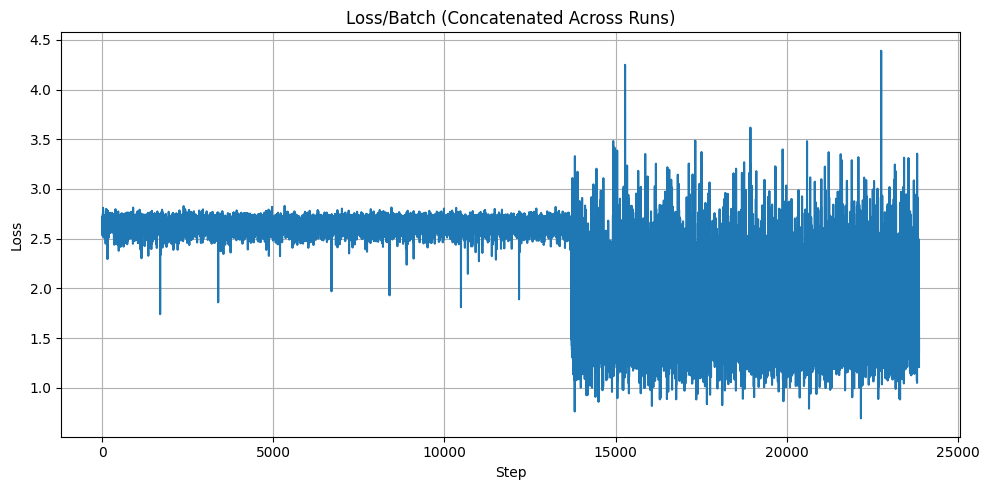

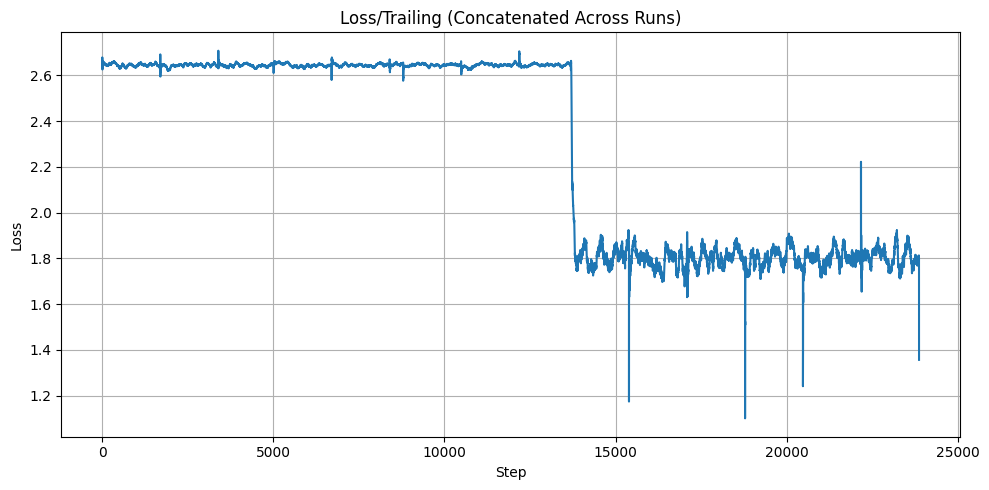

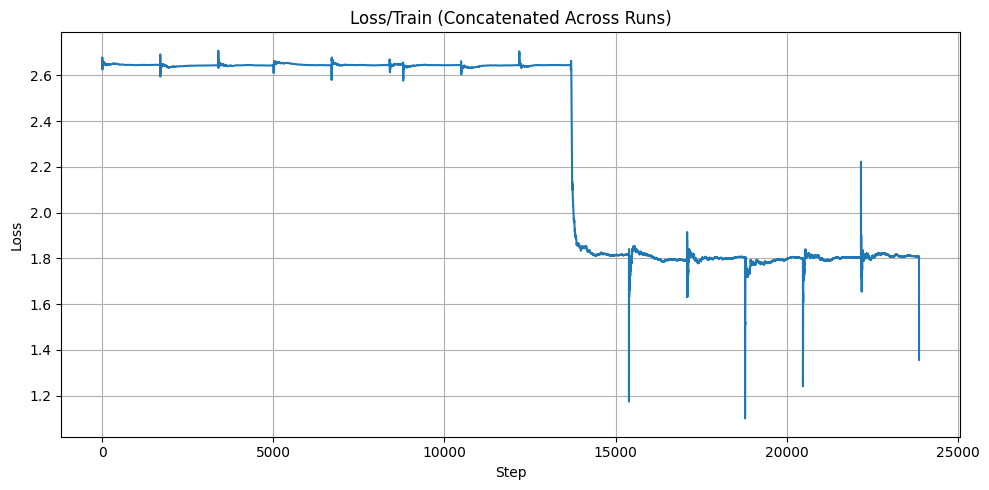

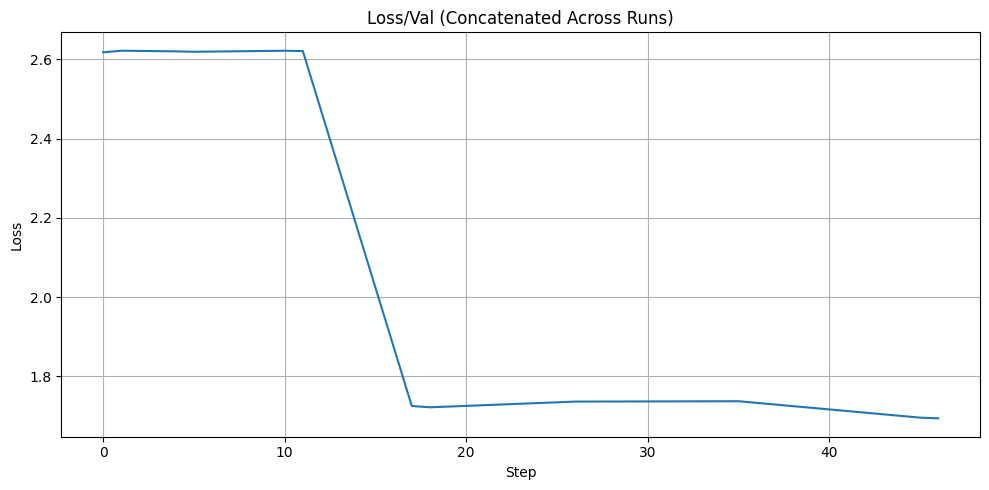

In [4]:
import matplotlib.pyplot as plt
import pandas as pd

# Load the combined dataframe
df = pd.read_csv("combined_tensorboard_losses.csv")

# Ensure proper ordering of runs (optional, based on filenames or order of training)
df = df.sort_values(by=['tag', 'run', 'step'])

# Container for plots
tags = df['tag'].unique()

for tag in tags:
    tag_df = df[df['tag'] == tag].copy()
    tag_df = tag_df.sort_values(by=['run', 'step'])

    # Reset step values so runs appear one after another
    tag_df['adjusted_step'] = 0
    step_offset = 0

    for run in tag_df['run'].unique():
        run_idx = tag_df['run'] == run
        tag_df.loc[run_idx, 'adjusted_step'] = tag_df.loc[run_idx, 'step'] + step_offset
        step_offset = tag_df.loc[run_idx, 'adjusted_step'].max() + 1  # small gap between runs

    # Plot
    plt.figure(figsize=(10, 5))
    plt.plot(tag_df['adjusted_step'], tag_df['loss'], label=tag)
    plt.title(f"{tag} (Concatenated Across Runs)")
    plt.xlabel("Step")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

